## Importar bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from datetime import datetime

## Cargar los datos y visualización

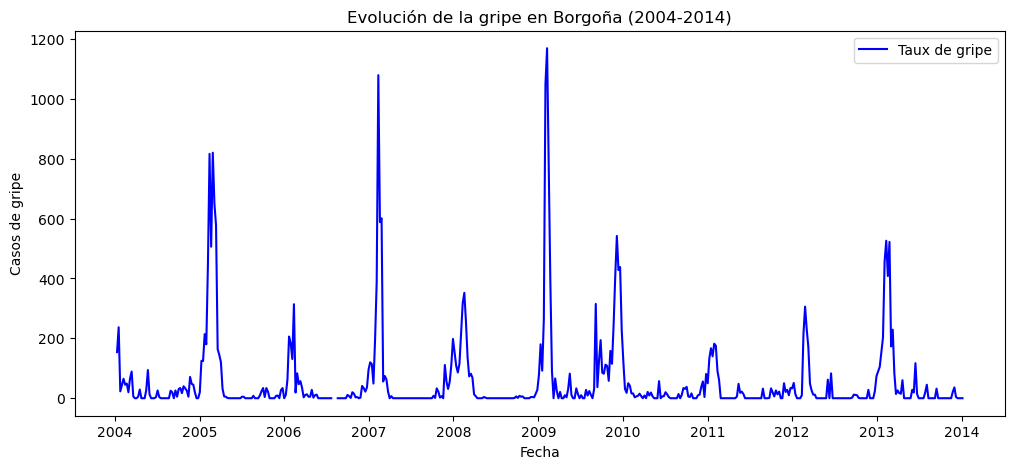

In [14]:
# Cargar el dataset (asegúrate de tener el archivo CSV en el mismo directorio)
df = pd.read_csv('gripe.csv')  # Ajusta el nombre si es diferente

# Visualizamos las primeras filas
df.head()

# Convertimos la columna 'week' a tipo fecha
df['week'] = pd.to_datetime(df['week'])
df = df.sort_values('week')  # Ordenamos por fecha

# Establecemos la columna 'week' como índice
df.set_index('week', inplace=True)

# Graficamos la serie temporal
plt.figure(figsize=(12,5))
plt.plot(df['TauxGrippe'], color='blue', label='Taux de gripe')
plt.xlabel('Fecha')
plt.ylabel('Casos de gripe')
plt.title('Evolución de la gripe en Borgoña (2004-2014)')
plt.legend()
plt.show()

## Descomposición y estacionariedad

C:\Users\nunoc\AppData\Local\Temp\ipykernel_26476\3893273970.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['TauxGrippe'] = df['TauxGrippe'].fillna(method='ffill')


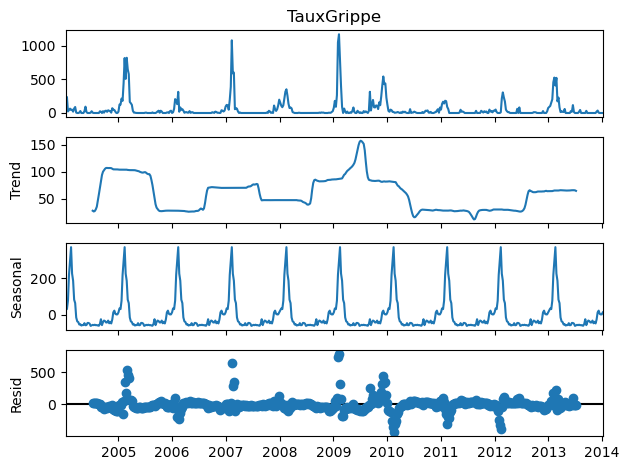

ADF Statistic: -7.749847637415055
p-value: 1.0088334966423746e-11


In [ ]:
# Rellenamos los valores nulos
df['TauxGrippe'] = df['TauxGrippe'].fillna(method='ffill')

# Descomposición
decompose_result = seasonal_decompose(df['TauxGrippe'], model='additive', period=52)
decompose_result.plot()
plt.show()

# Prueba de Dickey-Fuller aumentada (ADF) para verificar estacionariedad
adf_result = adfuller(df['TauxGrippe'])
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")

## Preprocesamiento y normalización

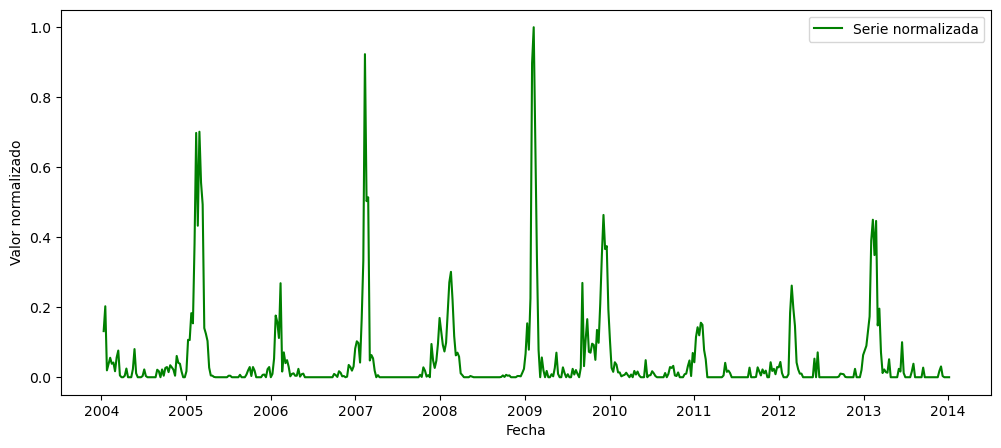

In [29]:
# Seleccionamos la columna objetivo y creamos un DataFrame para entrenamiento
values = df[['TauxGrippe']]

# Normalizamos los datos entre 0 y 1
scaler = MinMaxScaler()
values_scaled = scaler.fit_transform(values)

# Convertimos a DataFrame de nuevo
values_scaled_df = pd.DataFrame(values_scaled, index=values.index, columns=['TauxGrippe'])

# Visualizamos la serie normalizada
plt.figure(figsize=(12,5))
plt.plot(values_scaled_df, color='green', label='Serie normalizada')
plt.xlabel('Fecha')
plt.ylabel('Valor normalizado')
plt.legend()
plt.show()

## Modelo de ML: ARIMA

c:\Users\nunoc\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\nunoc\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\nunoc\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


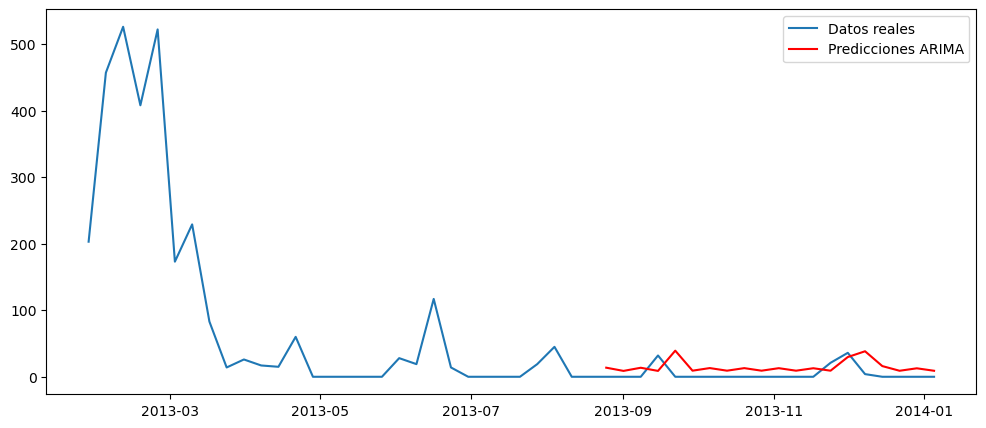

MAE: 14.316007281796072
RMSE: 16.546254363871654
R²: -1.3354463199670872


In [37]:
model_arima = ARIMA(df['TauxGrippe'], order=(2,1,2))  # Ajusta el orden según resultados
modelo_arima_fit = model_arima.fit()

# Pronóstico para el conjunto de prueba
predicciones_arima = modelo_arima_fit.predict(start=len(df)-20, end=len(df)-1, typ='levels')

# Visualizamos el pronóstico
plt.figure(figsize=(12,5))
plt.plot(df.index[-50:], df['TauxGrippe'][-50:], label='Datos reales')
plt.plot(df.index[-20:], predicciones_arima, color='red', label='Predicciones ARIMA')
plt.legend()
plt.show()

# Calculamos métricas
print('MAE:', mean_absolute_error(df['TauxGrippe'][-20:], predicciones_arima))
print('RMSE:', np.sqrt(mean_squared_error(df['TauxGrippe'][-20:], predicciones_arima)))
print('R²:', r2_score(df['TauxGrippe'][-20:], predicciones_arima))

# Modelo de Deep Learning: LSTM

Epoch [2/10], Loss: 0.0009
Epoch [4/10], Loss: 0.0002
Epoch [6/10], Loss: 0.0001
Epoch [8/10], Loss: 0.0002
Epoch [10/10], Loss: 0.0001


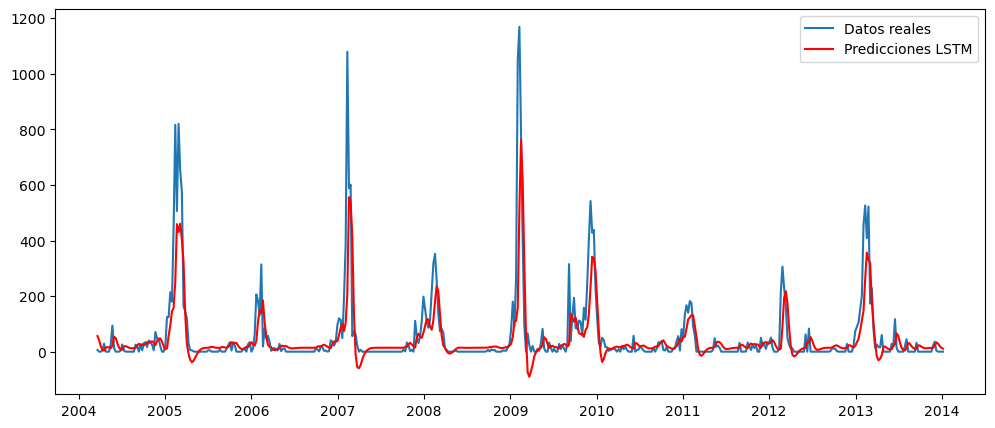

MAE: 39.181579165482056
RMSE: 91.292825320624
R²: 0.5779980830711117


In [55]:
# Creamos los datos en secuencias
sequence_length = 10
X_lstm, y_lstm = [], []
for i in range(len(values_scaled_df) - sequence_length):
    X_lstm.append(values_scaled_df.iloc[i:i+sequence_length].values)
    y_lstm.append(values_scaled_df.iloc[i+sequence_length].values)

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

# Convertimos a tensores
X_lstm_tensor = torch.Tensor(X_lstm)
y_lstm_tensor = torch.Tensor(y_lstm)

# Creamos dataset y dataloader
batch_size = 16
dataset_lstm = TensorDataset(X_lstm_tensor, y_lstm_tensor)
data_loader_lstm = DataLoader(dataset_lstm, batch_size=batch_size, shuffle=False)

# Definimos la arquitectura LSTM
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

model_lstm = LSTMModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(model_lstm.parameters(), lr=0.001)

# Entrenamiento
epochs = 10
for epoch in range(epochs):
    for X_batch, y_batch in data_loader_lstm:
        optimizer.zero_grad()
        outputs = model_lstm(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
    if (epoch+1) % 2 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# Predicciones finales
with torch.no_grad():
    y_pred = model_lstm(X_lstm_tensor).numpy()

# Desnormalizamos
predicciones_lstm = scaler.inverse_transform(y_pred)
reales_lstm = scaler.inverse_transform(y_lstm)

# Visualizamos
plt.figure(figsize=(12,5))
plt.plot(df.index[-len(predicciones_lstm):], reales_lstm, label='Datos reales')
plt.plot(df.index[-len(predicciones_lstm):], predicciones_lstm, color='red', label='Predicciones LSTM')
plt.legend()
plt.show()

# Métricas finales
print('MAE:', mean_absolute_error(reales_lstm, predicciones_lstm))
print('RMSE:', np.sqrt(mean_squared_error(reales_lstm, predicciones_lstm)))
print('R²:', r2_score(reales_lstm, predicciones_lstm))

In [60]:
# Guardamos las métricas en un DataFrame para comparar
resultados = pd.DataFrame({
    'Modelo': ['ARIMA', 'LSTM'],
    'MAE': [mean_absolute_error(df['TauxGrippe'][-20:], predicciones_arima), mean_absolute_error(reales_lstm, predicciones_lstm)],
    'RMSE': [np.sqrt(mean_squared_error(df['TauxGrippe'][-20:], predicciones_arima)), np.sqrt(mean_squared_error(reales_lstm, predicciones_lstm))],
    'R2': [r2_score(df['TauxGrippe'][-20:], predicciones_arima), r2_score(reales_lstm, predicciones_lstm)]
})

print(resultados)

  Modelo        MAE       RMSE        R2
0  ARIMA  14.316007  16.546254 -1.335446
1   LSTM  39.181579  91.292825  0.577998


### Conclusión General

En este estudio analizamos la evolución de la gripe en Borgoña entre 2004 y 2014, utilizando técnicas de análisis de series temporales, preprocesamiento y modelado con machine learning (ML) y deep learning (DL).

**La serie es estacionaria** según la prueba de Dickey-Fuller aumentada, que mostró un p-valor muy bajo (1.00e-11), confirmando que no presenta tendencias a largo plazo y tiene una media estable. Sin embargo, observamos una `estacionalidad anual`: los casos de gripe alcanzan picos fuertes durante los meses invernales y permanecen bajos en verano, repitiéndose este patrón cada año.

Para el preprocesamiento, decidimos normalizar los datos con `MinMaxScaler`. **Esto ayuda a que los modelos procesen la información de manera más eficiente, ya que aprenden mejor cuando las variables tienen magnitudes similares**. Además, rellenamos los valores nulos con ffill para mantener la coherencia temporal sin distorsionar la secuencia.

Como modelo de ML clásico, **elegimos `ARIMA` porque es un enfoque tradicional y bien probado para series temporales estacionarias. Sin embargo, como la serie presenta picos abruptos y no lineales. Elegimos `LSTM` porque está diseñada para aprender patrones temporales complejos y manejar dependencias largas, siendo especialmente eficaz en series con estacionalidad y fluctuaciones intensas**.

**Al comparar el rendimiento, encontramos que el modelo ARIMA mostró resultados pobres**: un R² negativo (-1.33) y errores moderados (MAE: 14.31, RMSE: 16.55). Esto se debe a que ARIMA no logra anticipar los picos de la gripe, adaptándose solo a las tendencias suaves. **Por otro lado, el LSTM mostró un ajuste mucho más robusto**: un R² de 0.58, lo que significa que explicó el 58% de la variabilidad observada. Aunque los errores absolutos (MAE: 39.18, RMSE: 91.29) parecen más altos que los de ARIMA, reflejan mejor la magnitud de los picos reales que el modelo clásico no predice.

En resumen, concluimos que la gripe en Borgoña tiene un comportamiento **estacional muy claro y que los modelos de deep learning, como LSTM, son más adecuados para capturar esta complejidad y prever el comportamiento futuro con mayor precisión**. Sin embargo, los modelos clásicos como ARIMA siguen siendo una buena referencia inicial para obtener una visión general y rápida de la serie.